# Lab: Relationships Between Categorical Features

A fictional telecommunications company wants to understand which customer groups had the greatest observed churn percentages. A customer **churned** if they left the company during the previous month.

You will use the reproducible analysis workflow:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can help answer it?
3. **Operation:** What should the code select, calculate, or compare?
4. **Check:** Does the result have the expected rows, columns, units, and possible values?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Learning goals

By the end of this lab, you should be able to:

- identify a target feature;
- describe the distribution of a categorical target;
- create count, joint-percentage, and conditional-percentage cross-tabs;
- choose a normalization direction from the question;
- check the denominator represented by a percentage;
- refine the visual design of a categorical comparison; and
- distinguish an observed relationship from a causal claim.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook's output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

Each row represents one customer in IBM's fictional telecommunications sample.

| Feature | Feature type | Description |
| --- | --- | --- |
| `customer_id` | Identifier | Anonymous customer identifier |
| `contract` | Categorical | Month-to-month, one-year, or two-year contract |
| `internet_service` | Categorical | DSL, fiber optic, or no internet service |
| `tech_support` | Categorical | Technical-support status |
| `payment_method` | Categorical | Customer's payment method |
| `paperless_billing` | Categorical | Whether the customer uses paperless billing |
| `churn` | Categorical target | Whether the customer left during the previous month |

The file contains 7,043 customers and no missing values in these fields. See `data/README.md` for provenance and preparation.


## Prepare the notebook

Import Pandas using its conventional alias `pd` and Matplotlib's `pyplot` component using its conventional alias `plt`.


In [1]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt

## Read the data

Read `data/telco_customer_churn.csv` into a DataFrame named `customers`.


In [2]:
# Write your code here.
customers = pd.read_csv("data/telco_customer_churn.csv")


## Check the data

Display the first five rows.


In [3]:
# Write your code here.
customers.head()

,customer_id,contract,internet_service,tech_support,payment_method,paperless_billing,churn
0,7590-VHVEG,Month-to-month,DSL,No,Electronic check,Yes,No
1,5575-GNVDE,One year,DSL,No,Mailed check,No,No
2,3668-QPYBK,Month-to-month,DSL,No,Mailed check,Yes,Yes
3,7795-CFOCW,One year,DSL,Yes,Bank transfer (automatic),No,No
4,9237-HQITU,Month-to-month,Fiber optic,No,Electronic check,Yes,Yes


## Check the features

Display a summary that includes the feature names, non-missing counts, and Pandas data storage types.


In [4]:
# Write your code here.
customers.info() # summary of item type
# Count the missing values in every feature.
# Display the missing-value count for every feature.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        7043 non-null   str  
 1   contract           7043 non-null   str  
 2   internet_service   7043 non-null   str  
 3   tech_support       7043 non-null   str  
 4   payment_method     7043 non-null   str  
 5   paperless_billing  7043 non-null   str  
 6   churn              7043 non-null   str  
dtypes: str(7)
memory usage: 777.4 KB


In [5]:
# Write your code here.
customers.isna().sum()

customer_id          0
contract             0
internet_service     0
tech_support         0
payment_method       0
paperless_billing    0
churn                0
dtype: int64

A **categorical** feature places observations into groups or labels. A **quantitative** feature records a numerical amount or measurement for which arithmetic is meaningful.


**Complete the table using the results above.** In the data type column, classify each feature as categorical or quantitative. In the data storage type column, record the type reported by Pandas. Different Pandas versions may display text as `str` or `object`.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `customer_id` | categorical | string | None |
| `contract` | categorical | string | None |
| `internet_service` | categorical | string | None |
| `tech_support` | categorical | string | None |
| `payment_method` | categorical | string | None |
| `paperless_billing` | categorical | string | None |
| `churn` | categorical | string | None |


## Identify the target


**Which feature is the target, and what outcome does it represent?**

Your answer: The column `churn` represents the target feature we are looking for. The outcome represents customers who had left the company in the previous month ( No money coming in )


## Describe the target distribution with counts

Create and display a Series named `churn_counts`.


In [6]:
# Write your code here.
churn_counts = customers['churn'].value_counts()

churn_counts


churn
No     5174
Yes    1869
Name: count, dtype: int64

**Which target outcome is more frequent?**

Your answer: From the sample of customers, 73% of customers stay with the company where as 27% leave.


## Describe the target distribution with relative frequencies

Create and display a Series named `churn_percent`.


In [7]:
# Write your code here.
churn_percent = customers['churn'].value_counts(normalize=True)*100

churn_percent


churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**What percentage of all customers churned?**

Your answer: 27% of all customers churned (left the company)


# Analysis 1: Is churn related to contract type?

Follow the analysis workflow from question through limitation.


In [8]:
#gotta check what the choices are
customers['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

**Before calculating a cross-tab, which contract type do you predict had the greatest churn percentage? Explain your prediction.**

Your answer: I believe the contract-type that has the greatest churn woudl be the Month-to-month. Because that this would contain a sub group of customers who are either new customers who want to try a new service, or those who can't afford it for more than a month. Most companies -from what I've seen- offer *cheaper* choices given they pay for a longer subscription.


## Step 1: Question


The question is: **Is churn related to contract type?**


## Step 2: Data

The relevant features are `contract` and `churn`. Before calculating percentages, compare the raw counts in their joint distribution.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.


In [9]:
# Write your code here.
contract_churn_counts = pd.crosstab(customers['churn'],customers['contract'])
contract_churn_counts


contract,Month-to-month,One year,Two year
churn,,,
No,2220,1307,1647
Yes,1655,166,48


**Which contract type has the greatest raw number of customers who churned?**

Your answer: The greatest raw number of customers were the Month-to-Month (as predicted)


**Do the raw churn counts establish which contract group was most likely to churn? Explain.**

Your answer: Yes. Because the majority amount of churns come from Month-to-month, we can establish that Month-to-month yielded higher churn rates.

#### **Some extra math**

**Month-to-Month Ratio** = $\frac{1655}{2290+1655}$ = 43% of Month-to-month customers leave

**One year Ratio** = $\frac{166}{1307+166}$ = 11% of One year customers leave

**Two year Ratio** = $\frac{48}{48+1647}$ = 3% of Two year customers leave

## Step 3: Operation

To compare likelihood fairly, calculate churn percentages within each contract type. First inspect the group totals.

Recreate the contract/churn cross-tab using `margins=True`.


In [10]:
# Write your code here.
pd.crosstab(customers['churn'],customers['contract'],margins=True)

contract,Month-to-month,One year,Two year,All
churn,,,,
No,2220,1307,1647,5174
Yes,1655,166,48,1869
All,3875,1473,1695,7043


**Why do the contract-group totals matter when comparing likelihood?**

Your answer: Contract-group totals matter because they are the denominators for the churn percentages. Without the total amount per contract, we could reach incorrect conclusions of each group.


### Joint percentages

Create and display `contract_joint_percent`. All cells together should add to 100%.


In [11]:
# Write your code here.
contract_joint_percent = pd.crosstab(customers['churn'],customers['contract'],margins=True, normalize=True)

contract_joint_percent

contract,Month-to-month,One year,Two year,All
churn,,,,
No,0.315207,0.185574,0.233849,0.73463
Yes,0.234985,0.023570,0.006815,0.26537
All,0.550192,0.209144,0.240664,1.00000


## Step 4: Check

Display the sum of every value in `contract_joint_percent`.


In [12]:
#sanity check 
pd.crosstab(customers['churn'],customers['contract'], margins=True)['Month-to-month']['Yes']/pd.crosstab(customers['churn'],customers['contract'], margins=True)['All']['Yes']

np.float64(0.8855002675227395)

In [13]:
# Write your code here.
print(round(contract_joint_percent['Month-to-month']['Yes']/contract_joint_percent['All']['Yes']*100,2), '% of customers leave the company with a Month-to-month contract')

print(round(contract_joint_percent['One year']['Yes']/contract_joint_percent['All']['Yes']*100,2), '% of customers leave the company with a One year contract')

print(round(contract_joint_percent['Two year']['Yes']/contract_joint_percent['All']['Yes']*100,2), '% of customers leave the company with a Two year contract')

88.55 % of customers leave the company with a Month-to-month contract
8.88 % of customers leave the company with a One year contract
2.57 % of customers leave the company with a Two year contract


**What denominator does each joint percentage use?**

Your answer: Each joint percentage uses the sum of that specific group as the denominator.


**Does the joint-percentage table directly answer which contract group was most likely to churn?**

Your answer: Yes, the joint-percentage table divides the categories up by contract group so we can see that majority of customers that have the Month-to-month contracts typically churn (88.55%). This shows which group has the most churn, but does not identify the cause.


### Conditional percentages

Create `churn_within_contract` so each row describes churn outcomes within one contract type.


In [14]:
# Write your code here.
churn_within_contract = pd.crosstab(customers['contract'],customers['churn'],normalize=True)

### Check the conditional percentages

Display the sum of each row in `churn_within_contract`.


In [15]:
# Write your code here.
# sum of each row
print(churn_within_contract.apply(lambda x: x.sum())*100)
# sum of all of the rows
print(churn_within_contract.apply(lambda x: x.sum()).sum())
# sanity check
# print(customers['customer_id'].count())
churn_within_contract

churn
No     73.463013
Yes    26.536987
dtype: float64
1.0


churn,No,Yes
contract,,
Month-to-month,0.315207,0.234985
One year,0.185574,0.023570
Two year,0.233849,0.006815


**What should every row add to, and why?**

Your answer: Every row should add to the sum of whether they said yes or no.


**Which contract group had the greatest observed churn percentage? Report the percentage.**

Your answer: The contract group with the greatest observed churn percentage was the Month-to-month with 88.55% of the total churn (overall churn from all contract groups)


**Was your prediction supported?**

Your answer: Yes.


## Step 5: Evidence

### Visualize the raw counts

Make a stacked bar chart from `contract_churn_counts`.


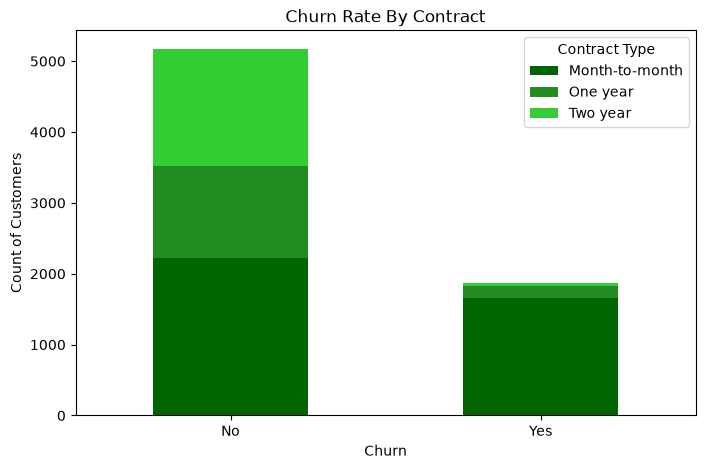

In [16]:
# Write your code here.
contract_churn_counts.plot(
    kind='bar',
    stacked=True,
    color=['darkgreen','forestgreen', 'limegreen'],
    figsize=(8,5)
)
plt.title('Churn Rate By Contract')
plt.xlabel('Churn')
plt.ylabel('Count of Customers')
plt.xticks(rotation=0)
plt.legend(title='Contract Type')
plt.show()

### Visualize the conditional percentages

Make a 100% stacked bar chart from `churn_within_contract`. Use:

- `"lightgray"` for customers who did not churn;
- `"steelblue"` for customers who churned;
- a question-focused title;
- descriptive axis labels;
- horizontal x-axis labels; and
- an audience-friendly legend.


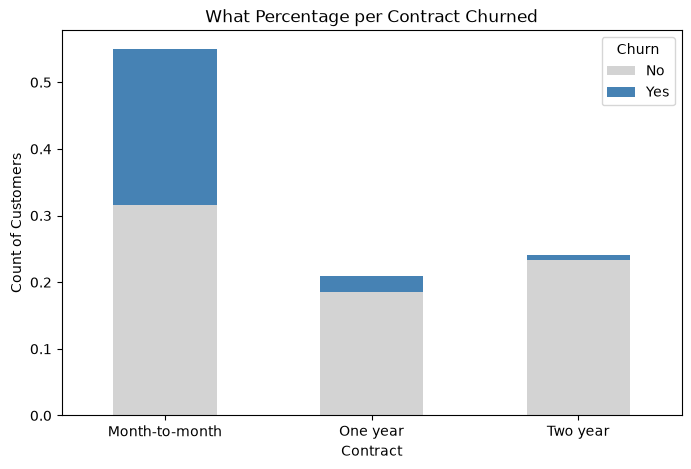

In [17]:
# Write your code here.
churn_within_contract.plot(
    kind='bar',
    stacked=True,
    color=['lightgray', 'steelblue'],
    figsize=(8,5)
)
plt.title('What Percentage per Contract Churned')
plt.xlabel('Contract')
plt.ylabel('Count of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Which chart answers the likelihood question more clearly: counts or conditional percentages? Explain.**

Your answer:Conditional percentage provides an easier to follow bar plot that separates each contract and stacks by whether if the customer churned or not. Because `contract_churn_counts`has the y-axis being the count, it can be difficult to distinguish the customers by contract.


## Step 6: Conclusion


**What conclusion about contract type and churn is supported by this sample?**

Your answer:The contract that appears to have the highest percentage, from the sample, is customers who use the Month-to-month contract.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's contract would cause a change in churn?**

Your answer: This analysis shows a relationship between contract type and churn, but does not prove that changing a customer's contract would change their likelihood of leaving. Other differences between the customers could help explain the pattern. More investigation is needed to find the cause and effect.


# Analysis 2: Is churn related to payment method?

Apply the same workflow to a second pair of categorical features.


## Step 1: Question


The question is: **Is churn related to payment method?**


## Step 2: Data

Create and display the joint distribution of `payment_method` and `churn` as raw counts. Name it `payment_churn_counts`.

Create and display `payment_churn_counts`.


In [18]:
# Write your code here.
payment_churn_counts = pd.crosstab(customers['payment_method'],customers['churn'])

payment_churn_counts

churn,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


## Step 3: Operation

Create and display `churn_within_payment`.


In [19]:
# Write your code here.
churn_within_payment = pd.crosstab(customers['payment_method'],customers['churn'],normalize=True)

churn_within_payment

churn,No,Yes
payment_method,,
Bank transfer (automatic),0.182593,0.036632
Credit card (automatic),0.183161,0.032941
Electronic check,0.183729,0.152066
Mailed check,0.185148,0.043731


## Step 4: Check

Display the sum of every row in `churn_within_payment`.


In [20]:
# Write your code here.
# print((churn_within_payment['Electronic check']['Yes']/churn_within_payment['Electronic check']['All'])*100)
churn_within_payment.sum()

churn
No     0.73463
Yes    0.26537
dtype: float64

**Which payment-method group had the greatest observed churn percentage? Report the percentage.**

Your answer: Electronic Check had the greatest observed churn rate with 45% of churning customers leaving the company.


## Step 5: Evidence

Make a 100% stacked bar chart. Choose two readable colors that are different from the `"lightgray"` and `"steelblue"` used in the contract chart. Use the same color consistently for each outcome throughout this chart and include audience-friendly labels.


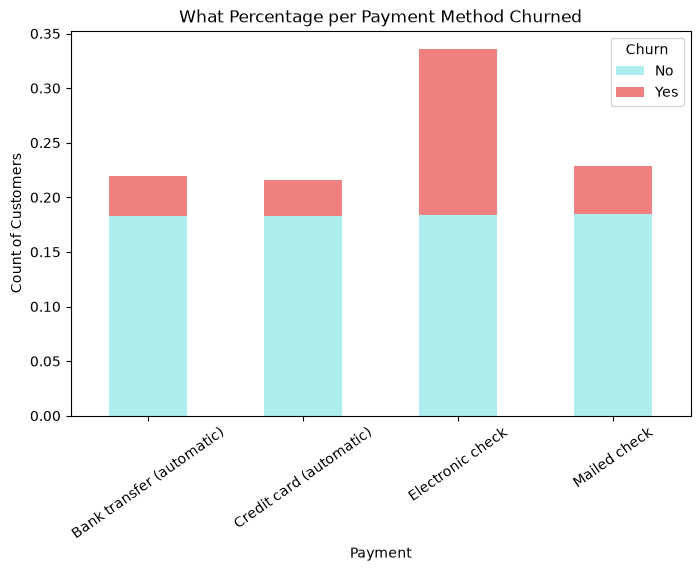

In [21]:
# Write your code here.
churn_within_payment.plot(
    kind='bar',
    stacked=True,
    color=['paleturquoise', 'lightcoral'],
    figsize=(8,5)
)
plt.title('What Percentage per Payment Method Churned')
plt.xlabel('Payment')
plt.ylabel('Count of Customers')
plt.xticks(rotation=35)
plt.legend(title='Churn')
plt.show()

## Step 6: Conclusion


**What conclusion about payment method and churn is supported by the sample? Include the percentage that provides your strongest evidence.**

Your answer: In this sample, customers who used electronic checks had the highest churn rate of 45.29%. This suggests a relationship between payment method and churn.

## Step 7: Limitation


**Why does this analysis not prove that changing a customer's payment method would cause a change in churn?**

Your answer:This analysis does not prove that changing a customer's payment method would change their likelihood of churning because other factors, such as customer satisfaction or contract type, could explain the relationship. The analysis compares existing customer groups; it does not test what happens when customers change payment methods.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that you did not use one.

Your answer:I used AI to help clarify the lab instructions and review my written answers. One suggestion I evaluated was to report the percentage of electronic-check customers who churned, rather than the percentage of churned customers who used electronic checks. I accepted this correction because the question asks about churn within each payment-method group. AI also helped me revise my limitation statements to explain why a relationship does not prove cause and effect.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Keep code, figures, and written answers neat and easy to read.
- Distinguish an observed relationship from a causal claim.
- Complete the AI-use reflection.
- Submit the completed notebook by the deadline.


In [22]:
#for funsies

pd.crosstab(customers['churn'],customers['internet_service'],normalize = 'columns')*100

internet_service,DSL,Fiber optic,No
churn,,,
No,81.040892,58.107235,92.59502
Yes,18.959108,41.892765,7.40498


Interesting... a small percentile of those using fiber optics would leave the company. I mean if they would go to a different company that provides fiber optics, that would make sense, but the cost of it to even install is ludicrous.

In [23]:
pd.crosstab(customers['churn'],customers['tech_support'], normalize='columns')*100

tech_support,No,No internet service,Yes
churn,,,
No,58.364526,92.59502,84.833659
Yes,41.635474,7.40498,15.166341


Customers without internet service had the lowest observed churn rate, which makes me curious whether service costs influence customers’ decisions to leave. I would investigate customers’ reasons for cancellation and test whether offering a voluntary service pause helps retention before recommending it.